# Log for Naive Bayes
### Student id: C00313459
### Name: Amisha Das

## 1. Introduction
This notebook explores the use of Naive Bayes machine learning model and its 2 subtypes, namely:
1. Gaussian Naive Bayes
2. Multinomial Naive Bayes


## 2. Gaussian Naive Bayes (GNB)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, KBinsDiscretizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv('diabetes.csv')


### About Dataset- 
This is a dataset about a patient's vitals and then a binary column where 0 signifies no diabetes and 1 signifies diabetes positive.

In [3]:
print("Dataset Info:\n", df.info())
print("\nFirst Few Rows:\n", df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   glucose        995 non-null    int64
 1   bloodpressure  995 non-null    int64
 2   diabetes       995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB
Dataset Info:
 None

First Few Rows:
    glucose  bloodpressure  diabetes
0       40             85         0
1       40             92         0
2       45             63         1
3       45             80         0
4       40             73         1


In [4]:
df = df.dropna()


Encoding labels to have numbers consumable by the ML model

In [5]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le


Allocating columns

In [6]:
X = df.iloc[:, :-1]  
y = df.iloc[:, -1] 

Standardising features

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Training the model.

20% reserved for test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Selecting Gaussian Naive Bayes and fitting data into the model.

In [9]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [10]:
y_pred = nb_model.predict(X_test)

Results of testing

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Model Accuracy: 0.9296482412060302

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        93
           1       0.93      0.93      0.93       106

    accuracy                           0.93       199
   macro avg       0.93      0.93      0.93       199
weighted avg       0.93      0.93      0.93       199



Confusion matrix:

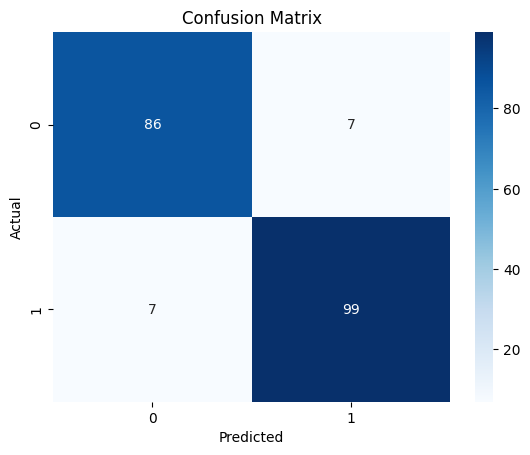

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Conclusion:
Results are excellent with 92% accuracy and confusion matrix with only 7 incorrect values.

### 2.1 Improving GNB Model Accuracy via PCA to reduce dimensionality

In [13]:
print("\nApplying PCA for Dimensionality Reduction:")
pca = PCA(n_components=0.95)  #reataning 95% variance
X_pca = pca.fit_transform(X_scaled)


Applying PCA for Dimensionality Reduction:


In [14]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


In [15]:
nb_model_pca = GaussianNB()
nb_model_pca.fit(X_train_pca, y_train)

GaussianNB()

In [16]:
y_pred_pca = nb_model_pca.predict(X_test_pca)

In [17]:
pca_accuracy = accuracy_score(y_test, y_pred_pca)
print("\nModel Accuracy after PCA:", pca_accuracy)
print("\nClassification Report after PCA:\n", classification_report(y_test, y_pred_pca))


Model Accuracy after PCA: 0.9296482412060302

Classification Report after PCA:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        93
           1       0.93      0.94      0.93       106

    accuracy                           0.93       199
   macro avg       0.93      0.93      0.93       199
weighted avg       0.93      0.93      0.93       199



### Conclusion:
Unimpressive results with close to no changes. Future work required.

## Multinomial NB

In [18]:
magic_df = pd.read_csv('magic.csv')

### About Dataset-
Major Atmospheric Gamma Imaging Cherenkov (MAGIC) telescope binary classification set to classify an event as gamma ray signal (g) or background noise from hardons (h)

Since the data was converted from a .data file, need to add features names.

In [19]:
feature_names = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
magic_df.columns = feature_names

In [20]:
magic_df['class'] = magic_df['class'].map({'g': 1, 'h': 0})

Feature decretizisation via bins, diving into 10 discrete bins. Discreet values are stronned in X_nagic_binned

In [21]:
kbins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
X_magic = magic_df.iloc[:, :-1]
y_magic = magic_df['class']
X_magic_binned = kbins.fit_transform(X_magic)

Splitting data into train and test sets (20-80)

In [22]:
X_train_magic, X_test_magic, y_train_magic, y_test_magic = train_test_split(X_magic_binned, y_magic, test_size=0.2, random_state=42)

Feeding sets into the Multinomial Naive Bayes Model.

In [23]:
multi_nb = MultinomialNB()
multi_nb.fit(X_train_magic, y_train_magic)

MultinomialNB()

Making Predictions

In [24]:
y_pred_magic = multi_nb.predict(X_test_magic)

In [25]:
multi_accuracy = accuracy_score(y_test_magic, y_pred_magic)
print("\nMultinomialNB Model Accuracy:", multi_accuracy)
print("\nMultinomialNB Classification Report:\n", classification_report(y_test_magic, y_pred_magic))


MultinomialNB Model Accuracy: 0.7860147213459516

MultinomialNB Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.63      0.68      1344
           1       0.81      0.87      0.84      2460

    accuracy                           0.79      3804
   macro avg       0.77      0.75      0.76      3804
weighted avg       0.78      0.79      0.78      3804



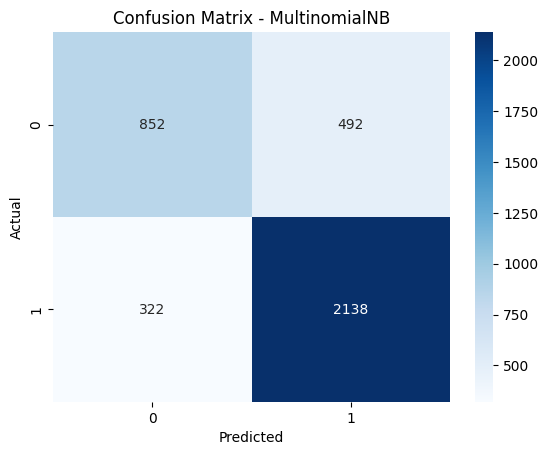

In [26]:
cm_magic = confusion_matrix(y_test_magic, y_pred_magic)
sns.heatmap(cm_magic, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - MultinomialNB')
plt.show()

### Conclusion:

Results are unimpressive at  78% accuracy and low recall and f1 scores. Further work required.